In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(PROJECT_ROOT)

d:\Property Intelligence Platform


In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from sklearn.decomposition import PCA

In [3]:
from src.data.ingestion import load_data

df= load_data("../data/feature_selection/gurgaon_properties_post_feature_selection_v2.csv")

Dataset loaded successfully.
Rows: 3553
Columns: 13


In [4]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,house,sector 92,0.85,4,4,3,Relatively New,1743.0,0,0,0,Low,Mid Floor
1,flat,sector 92,1.08,4,4,2,New Property,1891.0,1,0,0,Medium,High Floor
2,house,sector 33,8.00,4,4,3+,Old Property,7000.0,1,1,0,Medium,Low Floor
3,flat,sector 67a,1.60,3,3,2,New Property,1346.0,0,1,1,Medium,Mid Floor
4,house,sector 46,4.50,6,6,3+,Moderately Old,1845.0,0,1,1,Medium,Mid Floor


In [5]:
df['furnishing_type'].value_counts()

furnishing_type
0    2373
1     994
2     186
Name: count, dtype: int64

In [6]:
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished
df['furnishing_type'] = df['furnishing_type'].replace({0.0:'unfurnished',1.0:'semifurnished',2.0:'furnished'})

In [7]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,house,sector 92,0.85,4,4,3,Relatively New,1743.0,0,0,unfurnished,Low,Mid Floor
1,flat,sector 92,1.08,4,4,2,New Property,1891.0,1,0,unfurnished,Medium,High Floor
2,house,sector 33,8.00,4,4,3+,Old Property,7000.0,1,1,unfurnished,Medium,Low Floor
3,flat,sector 67a,1.60,3,3,2,New Property,1346.0,0,1,semifurnished,Medium,Mid Floor
4,house,sector 46,4.50,6,6,3+,Moderately Old,1845.0,0,1,semifurnished,Medium,Mid Floor


In [8]:
X = df.drop(columns=['price'])
y = df['price']

In [9]:
# Applying the log1p transformation to the target variable
y_transformed = np.log1p(y)

### Ordinal Encoding

In [10]:
columns_to_encode =['property_type', 'sector','balcony','agePossession','furnishing_type','luxury_category','floor_category']

In [11]:
# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1 ), columns_to_encode)
    ], 
    remainder='passthrough'
)

In [12]:
# Creating a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [13]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores= cross_val_score(pipeline, X, y_transformed, cv=kfold,scoring='r2')
scores.mean(), scores.std()

(np.float64(0.7275660807962135), np.float64(0.04429691501989375))

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)

In [15]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [16]:
y_pred = pipeline.predict(X_test)

In [17]:
y_pred = np.expm1(y_pred)

In [18]:
mean_absolute_error(np.expm1(y_test), y_pred)

1.0170127206533413

In [19]:
def scorer(model_name,model):

    output = []
    
    output.append(model_name)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')
    
    output.append(scores.mean())
    
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output
    

In [20]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor,ExtraTreesRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor


In [21]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [22]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

In [23]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])

In [24]:
model_df.sort_values(['mae'])

,name,r2,mae
10,xgboost,0.890403,0.546345
5,random forest,0.879873,0.568085
6,extra trees,0.866121,0.591131
7,gradient boosting,0.872867,0.618868
9,mlp,0.808319,0.735018
4,decision tree,0.783308,0.752313
8,adaboost,0.755122,0.820099
1,svr,0.751915,0.844474
2,ridge,0.727570,1.016793
0,linear_reg,0.727566,1.017013


### One Hot Encoding

In [25]:
# Creating a column transformer for preprocessing
columns_to_encode_2 =['property_type','balcony','luxury_category','floor_category']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1 ), columns_to_encode_2),
        ('cat1',OneHotEncoder(drop='first',handle_unknown='ignore'),['sector','agePossession','furnishing_type'])
    ], 
    remainder='passthrough'
)

In [26]:
# Creating a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [27]:
# K-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [28]:
scores.mean(), scores.std()

(np.float64(0.849670968551903), np.float64(0.02718670934622466))

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)

In [30]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
y_pred = pipeline.predict(X_test)

In [32]:
y_pred = np.expm1(y_pred)  # Inverse transformation to get predictions in original scale

In [33]:
mean_absolute_error(np.expm1(y_test),y_pred)

0.696389286961578

In [34]:
def scorer(model_name, model):
    
    output = []
    
    output.append(model_name)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')
    
    output.append(scores.mean())
    
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output

In [35]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [36]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Foun

In [37]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])
model_df.sort_values(['mae'])

,name,r2,mae
6,extra trees,0.881133,0.543271
10,xgboost,0.887408,0.557307
1,svr,0.880805,0.577519
9,mlp,0.869301,0.580238
5,random forest,0.869197,0.584561
7,gradient boosting,0.857959,0.652264
0,linear_reg,0.849671,0.696389
2,ridge,0.849995,0.697544
4,decision tree,0.787033,0.746460
8,adaboost,0.726691,0.881741


### OneHotEncoding With PCA

In [38]:
# Creating a column transformer for preprocessing
# Creating a column transformer for preprocessing
columns_to_encode_2 =['property_type','balcony','furnishing_type','luxury_category','floor_category']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1 ), columns_to_encode_2),
        ('cat1',OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'),['sector','agePossession'])
    ], 
    remainder='passthrough'
)

In [39]:
# Creating a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=0.95)),
    ('regressor', LinearRegression())
])

In [40]:
pipeline.get_feature_names_out

<bound method Pipeline.get_feature_names_out of Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['bedRoom', 'bathroom',
                                                   'built_up_area',
                                                   'servant room',
                                                   'store room']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['property_type', 'balcony',
                                                   'furnishing_type',
                                                   'luxury_category',
                                               

In [41]:
# K-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [42]:
scores.mean(), scores.std()

(np.float64(0.7544267302547787), np.float64(0.04104519594032054))

In [43]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [44]:
pipeline.named_steps['pca'].n_components_

np.int64(37)

In [45]:
pipeline.named_steps['pca'].explained_variance_ratio_

array([0.34529229, 0.10679388, 0.09523881, 0.070239  , 0.06676628,
       0.05084821, 0.04568302, 0.03362801, 0.03016725, 0.0191312 ,
       0.01478556, 0.01060551, 0.00760745, 0.00417898, 0.00342906,
       0.00321369, 0.00305948, 0.00295771, 0.00257918, 0.00250864,
       0.00247156, 0.00240805, 0.0022599 , 0.00203595, 0.00201924,
       0.00199633, 0.00195092, 0.00185327, 0.00180303, 0.00170892,
       0.00168228, 0.00166829, 0.00165854, 0.00161501, 0.00160603,
       0.00157918, 0.00153289])

In [46]:
X_pca = pipeline.named_steps['pca'].transform(
    pipeline.named_steps['preprocessor'].transform(X_train)
)

print(X_pca.shape)

(2842, 37)


In [47]:
def scorer(model_name, model):
    
    output = []
    
    output.append(model_name)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('pca', PCA(n_components=0.95)),
        ('regressor', model)
    ])
    
    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')
    
    output.append(scores.mean())
    
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output

In [48]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [49]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Foun

In [50]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])
model_df.sort_values(['mae'])

,name,r2,mae
6,extra trees,0.838760,0.630108
10,xgboost,0.833339,0.666240
5,random forest,0.824250,0.671250
9,mlp,0.827970,0.679825
7,gradient boosting,0.821452,0.718353
1,svr,0.825297,0.725500
8,adaboost,0.689459,0.921410
4,decision tree,0.619564,0.967163
2,ridge,0.754496,0.992762
0,linear_reg,0.754427,0.993921


### Target Encoding

In [51]:
import category_encoders as ce

columns_to_encode_3 = ['property_type', 'balcony', 'furnishing_type', 'luxury_category', 'floor_category']

# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1), columns_to_encode_3),
        ('cat1',OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'),['agePossession']),
        ('target_enc', ce.TargetEncoder(), ['sector'])
    ], 
    remainder='passthrough'
)

In [52]:
#!pip install category_encoders

In [53]:
# Creating a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [54]:
# K-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

In [55]:
scores.mean(),scores.std()

(np.float64(0.821408678662011), np.float64(0.023813136821741524))

In [56]:
def scorer(model_name, model):
    
    output = []
    
    output.append(model_name)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')
    
    output.append(scores.mean())
    
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output
    

In [57]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [58]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

In [59]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])
model_df.sort_values(['mae'])

,name,r2,mae
6,extra trees,0.890002,0.517808
5,random forest,0.890618,0.518781
10,xgboost,0.892205,0.536362
7,gradient boosting,0.883011,0.551567
1,svr,0.860131,0.604461
9,mlp,0.851275,0.640023
8,adaboost,0.816438,0.707473
0,linear_reg,0.821409,0.741690
2,ridge,0.821428,0.742082
4,decision tree,0.803190,0.801156


### Hyperparameter Tuning

In [60]:
from sklearn.model_selection import GridSearchCV

In [61]:
param_grid = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [None, 10, 20],
    'regressor__max_samples':[0.1, 0.25, 0.5, 1.0],
    'regressor__max_features': [ 'log2', 'sqrt']
}

In [62]:
columns_to_encode = ['property_type','sector', 'balcony', 'agePossession', 'furnishing_type', 'luxury_category', 'floor_category']

# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1), columns_to_encode),
        ('cat1',OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'),['agePossession']),
        ('target_enc', ce.TargetEncoder(), ['sector'])
    ], 
    remainder='passthrough'
)

In [63]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor())
])

In [64]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

In [65]:
search = GridSearchCV(pipeline, param_grid, cv=kfold, scoring='r2', n_jobs=-1, verbose=4)

In [66]:
search.fit(X, y_transformed)

Fitting 10 folds for each of 72 candidates, totalling 720 fits


,estimator,Pipeline(step...Regressor())])
,param_grid,"{'regressor__max_depth': [None, 10, ...], 'regressor__max_features': ['log2', 'sqrt'], 'regressor__max_samples': [0.1, 0.25, ...], 'regressor__n_estimators': [50, 100, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,4
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...), ...]"


In [67]:
final_pipe = search.best_estimator_

In [68]:
search.best_params_

{'regressor__max_depth': None,
 'regressor__max_features': 'sqrt',
 'regressor__max_samples': 1.0,
 'regressor__n_estimators': 200}

In [69]:
search.best_score_

np.float64(0.8992705572672657)

In [70]:
! pip install optuna


Defaulting to user installation because normal site-packages is not writeable


In [71]:
import optuna

print(optuna.__version__)

4.9.0


In [72]:
import optuna
def objective(trial):

    model_name = trial.suggest_categorical(
        "model",
        [
            "RandomForest",
            "ExtraTrees",
            "GradientBoosting",
            "XGBoost",
            "SVR"
        ]
    )

    # ---------------- Random Forest ---------------- #

    if model_name == "RandomForest":

        params = {
            "n_estimators": trial.suggest_int("rf_n_estimators",100,300),
            "max_depth": trial.suggest_int("rf_max_depth",5,30),
            "min_samples_split": trial.suggest_int("rf_min_samples_split",2,10),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
            "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", None]),
            "bootstrap": trial.suggest_categorical("bootstrap",[True, False]),
            "random_state":42,
            "n_jobs":1
        }

        model = RandomForestRegressor(**params)

    # ---------------- Extra Trees ---------------- #

    elif model_name == "ExtraTrees":

        params = {
            "n_estimators": trial.suggest_int("et_n_estimators",50,200),
            "max_depth": trial.suggest_int("et_max_depth",5,30),
            "min_samples_split": trial.suggest_int("et_min_samples_split",2,10),
            "random_state":42,
            "n_jobs":1
        }

        model = ExtraTreesRegressor(**params)

    # ---------------- Gradient Boosting ---------------- #

    elif model_name == "GradientBoosting":

        params = {
            "n_estimators": trial.suggest_int("gb_n_estimators",50,400),
            "learning_rate": trial.suggest_float("gb_learning_rate",0.01,0.3),
            "max_depth": trial.suggest_int("gb_max_depth",2,8),
            "random_state":42
        }

        model = GradientBoostingRegressor(**params)

    # ---------------- XGBoost ---------------- #

    elif model_name == "XGBoost":

        params = {
            "n_estimators": trial.suggest_int("xgb_n_estimators",20,350),
            "learning_rate": trial.suggest_float("xgb_learning_rate",0.01,0.3),
            "max_depth": trial.suggest_int("max_depth", 3, 15),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 15),
            "gamma": trial.suggest_float("gamma", 0, 10),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
            "colsample_bynode": trial.suggest_float("colsample_bynode", 0.5, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 100, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 100, log=True),
            "max_delta_step": trial.suggest_int("max_delta_step", 0, 10),
            "random_state":42,
            "n_jobs":1
        }

        model = XGBRegressor(**params)

    # ---------------- SVR ---------------- #

    else:

        params = {
            "C": trial.suggest_float("svr_C",0.1,100,log=True),
            "gamma": trial.suggest_categorical("svr_gamma",["scale","auto"]),
            "kernel": trial.suggest_categorical("svr_kernel",["rbf","linear"])
        }

        model = SVR(**params)

    # ---------------- Pipeline ---------------- #

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    score = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="r2",
        n_jobs=1
    ).mean()

    return score

In [73]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)   # Bayesian Optimization
)

study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=True,
    n_jobs=-1
)

[I 2026-08-08 23:24:11,966] A new study created in memory with name: no-name-e5f79a0f-e10f-4dd5-b45a-c790d10764eb


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-08-08 23:24:15,864] Trial 3 finished with value: 0.8489162509180408 and parameters: {'model': 'XGBoost', 'xgb_n_estimators': 169, 'xgb_learning_rate': 0.03855767699635579, 'max_depth': 6, 'min_child_weight': 4, 'gamma': 3.610685772340929, 'subsample': 0.6888731473472005, 'colsample_bytree': 0.8576354011177101, 'colsample_bylevel': 0.9601784717678838, 'colsample_bynode': 0.8956992654924454, 'reg_alpha': 2.325834889874309e-05, 'reg_lambda': 2.3822051759642204e-06, 'max_delta_step': 2}. Best is trial 3 with value: 0.8489162509180408.
[I 2026-08-08 23:24:16,499] Trial 5 finished with value: 0.6094609091781542 and parameters: {'model': 'SVR', 'svr_C': 0.2473090461408552, 'svr_gamma': 'scale', 'svr_kernel': 'rbf'}. Best is trial 3 with value: 0.8489162509180408.
[I 2026-08-08 23:24:16,531] Trial 0 finished with value: 0.8742767866940195 and parameters: {'model': 'GradientBoosting', 'gb_n_estimators': 63, 'gb_learning_rate': 0.14692916828053376, 'gb_max_depth': 2}. Best is trial 0 wit

In [74]:
print("Best Score :", study.best_value)
print()
print("Best Parameters:")
print(study.best_params)

Best Score : 0.9080341731385847

Best Parameters:
{'model': 'GradientBoosting', 'gb_n_estimators': 326, 'gb_learning_rate': 0.0641749260323308, 'gb_max_depth': 6}


In [75]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

trials = study.trials_dataframe()
trials = trials.sort_values("value", ascending=False)
trials.head(10)

,number,value,datetime_start,datetime_complete,duration,params_bootstrap,params_colsample_bylevel,params_colsample_bynode,params_colsample_bytree,params_et_max_depth,params_et_min_samples_split,params_et_n_estimators,params_gamma,params_gb_learning_rate,params_gb_max_depth,params_gb_n_estimators,params_max_delta_step,params_max_depth,params_max_features,params_min_child_weight,params_min_samples_leaf,params_model,params_reg_alpha,params_reg_lambda,params_rf_max_depth,params_rf_min_samples_split,params_rf_n_estimators,params_subsample,params_svr_C,params_svr_gamma,params_svr_kernel,params_xgb_learning_rate,params_xgb_n_estimators,state
76,76,0.908034,2026-08-08 23:27:21.414338,2026-08-08 23:27:43.590409,0 days 00:00:22.176071,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.064175,6.0,326.0,NaN,NaN,NaN,NaN,NaN,GradientBoosting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
99,99,0.908000,2026-08-08 23:28:23.726892,2026-08-08 23:28:40.640692,0 days 00:00:16.913800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.035951,6.0,367.0,NaN,NaN,NaN,NaN,NaN,GradientBoosting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
70,70,0.907653,2026-08-08 23:26:59.622007,2026-08-08 23:27:24.149130,0 days 00:00:24.527123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.083061,6.0,328.0,NaN,NaN,NaN,NaN,NaN,GradientBoosting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
93,93,0.907607,2026-08-08 23:28:01.158316,2026-08-08 23:28:27.027501,0 days 00:00:25.869185,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.038796,6.0,357.0,NaN,NaN,NaN,NaN,NaN,GradientBoosting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
80,80,0.907553,2026-08-08 23:27:26.283415,2026-08-08 23:27:50.527877,0 days 00:00:24.244462,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.052851,6.0,339.0,NaN,NaN,NaN,NaN,NaN,GradientBoosting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
69,69,0.907510,2026-08-08 23:26:58.467854,2026-08-08 23:27:21.396113,0 days 00:00:22.928259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.086360,6.0,317.0,NaN,NaN,NaN,NaN,NaN,GradientBoosting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
98,98,0.907500,2026-08-08 23:28:23.573436,2026-08-08 23:28:40.580622,0 days 00:00:17.007186,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.034682,6.0,367.0,NaN,NaN,NaN,NaN,NaN,GradientBoosting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
79,79,0.907474,2026-08-08 23:27:24.168144,2026-08-08 23:27:48.872870,0 days 00:00:24.704726,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.060695,6.0,346.0,NaN,NaN,NaN,NaN,NaN,GradientBoosting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
92,92,0.907420,2026-08-08 23:27:58.287788,2026-08-08 23:28:23.558319,0 days 00:00:25.270531,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.036015,6.0,360.0,NaN,NaN,NaN,NaN,NaN,GradientBoosting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
8,8,0.907398,2026-08-08 23:24:15.893417,2026-08-08 23:24:45.167236,0 days 00:00:29.273819,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.136734,5.0,292.0,NaN,NaN,NaN,NaN,NaN,GradientBoosting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE


In [76]:
study.trials_dataframe()['params_model'].value_counts()

params_model
GradientBoosting    62
ExtraTrees          13
SVR                 12
XGBoost              7
RandomForest         6
Name: count, dtype: int64

In [77]:
def create_model(trial):

    model_name = trial["params_model"]

    if model_name == "RandomForest":
        model = RandomForestRegressor(
            n_estimators=int(trial["params_rf_n_estimators"]),
            max_depth=int(trial["params_rf_max_depth"]),
            min_samples_split=int(trial["params_rf_min_samples_split"]),
            min_samples_leaf=int(trial["params_min_samples_leaf"]),
            max_features=trial["params_max_features"],
            bootstrap=trial["params_bootstrap"],
            random_state=42,
            n_jobs=1
        )

    elif model_name == "ExtraTrees":
        model = ExtraTreesRegressor(
            n_estimators=int(trial["params_et_n_estimators"]),
            max_depth=int(trial["params_et_max_depth"]),
            min_samples_split=int(trial["params_et_min_samples_split"]),
            random_state=42,
            n_jobs=1
        )

    elif model_name == "GradientBoosting":
        model = GradientBoostingRegressor(
            n_estimators=int(trial["params_gb_n_estimators"]),
            learning_rate=trial["params_gb_learning_rate"],
            max_depth=int(trial["params_gb_max_depth"]),
            random_state=42
        )

    elif model_name == "XGBoost":
        model = XGBRegressor(
            n_estimators=int(trial["params_xgb_n_estimators"]),
            learning_rate=trial["params_xgb_learning_rate"],
            max_depth=int(trial["params_max_depth"]),
            min_child_weight=int(trial["params_min_child_weight"]),
            gamma=trial["params_gamma"],
            subsample=trial["params_subsample"],
            colsample_bytree=trial["params_colsample_bytree"],
            colsample_bylevel=trial["params_colsample_bylevel"],
            colsample_bynode=trial["params_colsample_bynode"],
            reg_alpha=trial["params_reg_alpha"],
            reg_lambda=trial["params_reg_lambda"],
            max_delta_step=int(trial["params_max_delta_step"]),
            random_state=42,
            n_jobs=1
        )

    else:
        model = SVR(
            C=trial["params_svr_C"],
            gamma=trial["params_svr_gamma"],
            kernel=trial["params_svr_kernel"]
        )

    return model

In [78]:
from sklearn.metrics import r2_score, mean_absolute_error

def evaluate_model(model):

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    return {
        "Train R2": r2_score(y_train, train_pred),
        "Test R2": r2_score(y_test, test_pred),
        "Train MAE": mean_absolute_error(np.expm1(y_train), np.expm1(train_pred)),
        "Test MAE": mean_absolute_error(np.expm1(y_test), np.expm1(test_pred))
    }

In [79]:
top5 = trials.head(20).copy()
results = []

for i in range(top5.shape[0]):

    trial = top5.iloc[i]

    model = create_model(trial)

    scores = evaluate_model(model)

    scores["CV R2"] = trial["value"]
    scores["Model"] = trial["params_model"]

    results.append(scores)

results_df = pd.DataFrame(results)

results_df

,Train R2,Test R2,Train MAE,Test MAE,CV R2,Model
0,0.989890,0.871560,0.143175,0.513183,0.908034,GradientBoosting
1,0.982533,0.870983,0.197124,0.514822,0.908000,GradientBoosting
2,0.993450,0.871884,0.113328,0.503141,0.907653,GradientBoosting
3,0.983882,0.874865,0.188876,0.506779,0.907607,GradientBoosting
4,0.987903,0.870493,0.162894,0.515837,0.907553,GradientBoosting
5,0.993910,0.874900,0.115280,0.502817,0.907510,GradientBoosting
6,0.981803,0.869407,0.203396,0.516733,0.907500,GradientBoosting
7,0.990174,0.869425,0.146434,0.512774,0.907474,GradientBoosting
8,0.982389,0.870966,0.199097,0.511414,0.907420,GradientBoosting
9,0.990660,0.877068,0.137187,0.502388,0.907398,GradientBoosting


In [80]:
best_trial = top5.iloc[19]

best_trial

number                                                 77
value                                            0.906011
datetime_start                 2026-08-08 23:27:21.810734
datetime_complete              2026-08-08 23:27:45.712504
duration                           0 days 00:00:23.901770
params_bootstrap                                      NaN
params_colsample_bylevel                              NaN
params_colsample_bynode                               NaN
params_colsample_bytree                               NaN
params_et_max_depth                                   NaN
params_et_min_samples_split                           NaN
params_et_n_estimators                                NaN
params_gamma                                          NaN
params_gb_learning_rate                          0.143208
params_gb_max_depth                                   6.0
params_gb_n_estimators                              337.0
params_max_delta_step                                 NaN
params_max_dep

In [81]:
final_model = create_model(best_trial)

In [82]:
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", final_model)
])

final_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [83]:
train_pred = final_pipeline.predict(X_train)
test_pred = final_pipeline.predict(X_test)

print("Train R2 :", r2_score(y_train, train_pred))
print("Test R2 :", r2_score(y_test, test_pred))

print("Train MAE :", mean_absolute_error(np.expm1(y_train), np.expm1(train_pred)))
print("Test MAE :", mean_absolute_error(np.expm1(y_test), np.expm1(test_pred)))

Train R2 : 0.9979733391762837
Test R2 : 0.8650692596334258
Train MAE : 0.06160593285030274
Test MAE : 0.5156321507180239


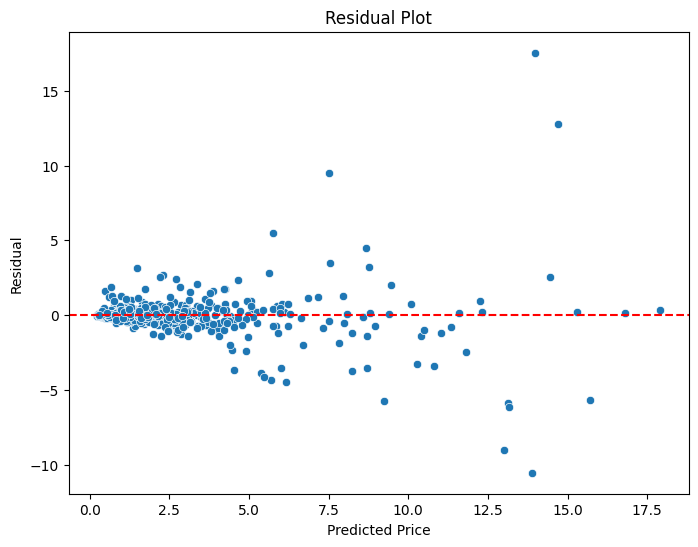

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predictions on test data
y_pred = final_pipeline.predict(X_test)

# Convert back from log scale
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred)

# Residuals
residuals = y_test_actual - y_pred_actual

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred_actual, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

### Exporting the model

In [85]:
import pickle
import os

os.makedirs("../artifacts", exist_ok=True)

with open("../artifacts/final_pipeline.pkl", "wb") as f:
    pickle.dump(final_pipeline, f)

print("Final pipeline saved successfully!")

Final pipeline saved successfully!


In [86]:
import pickle
import numpy as np

with open("../artifacts/final_pipeline.pkl", "rb") as f:
    loaded_pipeline = pickle.load(f)

original_pred = final_pipeline.predict(X_test)
loaded_pred = loaded_pipeline.predict(X_test)

print("Same predictions:",
      np.allclose(original_pred, loaded_pred))

Same predictions: True
